<a href="https://colab.research.google.com/github/geosconsulting/vari/blob/main/YEL_2_0_Inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# YEL 2.0 wind-field inference

This notebook downloads the public **SustainableUrbanSystemsLab/Yel-2.0** ONNX model and runs inference with its 8-channel, 504 × 504 feature layout.

> Important: YEL 1.0 is a different, 3-channel GAN architecture. This notebook intentionally uses **YEL 2.0**.

Your input CSV should contain one row per 2 m grid point and these columns:

| Column | Meaning |
|---|---|
| `x`, `y` | World coordinates in metres |
| `z_relative` | Evaluation height relative to the local ground/building datum (m) |
| `sdf` | Signed-distance feature (m; typically negative distance to the nearest building) |
| `building_height` | Building height at the point (m) |
| `u_ratio` | Atmospheric-profile velocity at `z_relative`, divided by reference velocity |

By default, the notebook loads these features from the public `Test.csv` file in the YEL 2.0 Hugging Face repository. You can instead provide a local or uploaded CSV file.

In [1]:
# NVIDIA T4 / CUDA runtime (for example, Google Colab)
# ORT 1.27+ uses CUDA 13; pin 1.26.0 for current CUDA 12 T4 runtimes.
%pip install -q numpy pandas matplotlib onnxruntime-gpu==1.26.0 huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.0/277.0 MB 3.9 MB/s eta 0:00:00


In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
from huggingface_hub import hf_hub_download

MODEL_REPO = "SustainableUrbanSystemsLab/Yel-2.0"
MODEL_FILE = "Yel.onnx"

H = W = 504
CHANNELS = 8
X_MIN, X_MAX, X_STEP = -485.0, 521.0, 2.0
Y_MIN, Y_MAX, Y_STEP = -514.5, 491.5, 2.0
REQUIRED_COLUMNS = ["x", "y", "z_relative", "sdf", "building_height", "u_ratio"]

# User settings
INPUT_CSV_URL = "https://huggingface.co/SustainableUrbanSystemsLab/Yel-2.0/resolve/main/Test.csv"
LOCAL_CSV = None  # Example: Path("/content/my_features.csv")
WIND_DIRECTIONS_DEG = list(range(0, 360, 45))  # 0°, 45°, ..., 315°
REFERENCE_WIND_SPEED = 5.0  # Uref in m/s
OUTPUT_CSV = Path("yel_predictions.csv")

## Load input CSV

The hosted `Test.csv` is used when `LOCAL_CSV` is `None`.

To use your own file in Google Colab:

1. Open the **Files** panel on the left.
2. Click **Upload to session storage** and select your CSV.
3. Set `LOCAL_CSV = Path("/content/your_file.csv")` in the settings cell.

Your CSV must contain the required columns listed at the top of this notebook.

In [3]:
if LOCAL_CSV is None:
    input_source = INPUT_CSV_URL
else:
    input_source = Path(LOCAL_CSV)
    if not input_source.is_file():
        raise FileNotFoundError(f"Could not find local CSV: {input_source.resolve()}")

features = pd.read_csv(input_source)
print(f"Loaded {len(features):,} rows from {input_source}")

missing = sorted(set(REQUIRED_COLUMNS) - set(features.columns))
if missing:
    raise ValueError(f"Missing required CSV columns: {missing}")
if features[REQUIRED_COLUMNS].isna().any().any():
    raise ValueError("The required feature columns contain missing values.")

features.head()

Loaded 200,252 rows from https://huggingface.co/SustainableUrbanSystemsLab/Yel-2.0/resolve/main/Test.csv


,x,y,z_relative,sdf,building_height,u_ratio
0,-485,-54.5,1.8,-291.22,0.0,0.26
1,-485,-52.5,1.8,-290.96,0.0,0.26
2,-485,-50.5,1.8,-290.71,0.0,0.26
3,-485,-48.5,1.8,-290.48,0.0,0.26
4,-485,-46.5,1.8,-290.26,0.0,0.26


## Download and inspect YEL 2.0

In [4]:
model_path = Path(hf_hub_download(repo_id=MODEL_REPO, filename=MODEL_FILE))
available_providers = ort.get_available_providers()
providers = (
    ["CUDAExecutionProvider", "CPUExecutionProvider"]
    if "CUDAExecutionProvider" in available_providers
    else ["CPUExecutionProvider"]
)
session = ort.InferenceSession(str(model_path), providers=providers)

input_meta = session.get_inputs()[0]
output_meta = session.get_outputs()[0]
print(f"Available execution providers: {available_providers}")
print(f"Active execution providers:    {session.get_providers()}")
print(f"Model:  {model_path}")
print(f"Input:  {input_meta.name} {input_meta.shape} ({input_meta.type})")
print(f"Output: {output_meta.name} {output_meta.shape} ({output_meta.type})")

shape = input_meta.shape
known_shape = tuple(v if isinstance(v, int) else None for v in shape)
expected = (1, CHANNELS, H, W)
if any(actual is not None and actual != wanted for actual, wanted in zip(known_shape, expected)):
    raise ValueError(
        f"Expected a YEL 2.0 input compatible with {expected}, but the model reports {shape}. "
        "Make sure you did not download YEL 1.0."
    )

Yel.onnx: reconstructing file:   0%|          |  0.00B /  187MB            

Yel.onnx: downloading bytes:           |  0.00B            

Available execution providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
Active execution providers:    ['CPUExecutionProvider']
Model:  /root/.cache/huggingface/hub/models--SustainableUrbanSystemsLab--Yel-2.0/snapshots/7ab6a39e12655444da816521867a1c3e24a3cc12/Yel.onnx
Input:  input ['batch_size', 8, 504, 504] (tensor(float))
Output: wind_field ['batch_size', 1, 504, 504] (tensor(float))


## Assemble model input tensors

Channels are: `x`, `y`, `z_relative`, `sdf`, `building_height`, `u_ratio`, `-sin(direction)`, and `-cos(direction)`. Feature values and direction values are scattered only at supplied grid points, matching the plugin.

In [5]:
def prepare_base_tensor(frame):
    data = frame.copy().reset_index(drop=True)
    ix = np.rint((data["x"].to_numpy() - X_MIN) / X_STEP).astype(np.int64)
    iy = np.rint((data["y"].to_numpy() - Y_MIN) / Y_STEP).astype(np.int64)
    valid = (ix >= 0) & (ix < W) & (iy >= 0) & (iy < H)
    if not valid.any():
        raise ValueError("No input points fall inside YEL's fixed world grid.")

    tensor = np.zeros((1, CHANNELS, H, W), dtype=np.float32)
    tensor[0, 0] = np.broadcast_to(np.linspace(X_MIN, X_MAX, W, dtype=np.float32), (H, W))
    tensor[0, 1] = np.broadcast_to(np.linspace(Y_MIN, Y_MAX, H, dtype=np.float32)[:, None], (H, W))

    rows, cols = iy[valid], ix[valid]
    for channel, column in enumerate(REQUIRED_COLUMNS[2:], start=2):
        tensor[0, channel, rows, cols] = data.loc[valid, column].to_numpy(dtype=np.float32)

    return data, tensor, ix, iy, valid


def tensor_for_direction(base_tensor, ix, iy, valid, direction_deg):
    tensor = base_tensor.copy()
    radians = np.deg2rad(direction_deg)
    rows, cols = iy[valid], ix[valid]
    tensor[0, 6, rows, cols] = np.float32(-np.sin(radians))
    tensor[0, 7, rows, cols] = np.float32(-np.cos(radians))
    return tensor


data, base_tensor, grid_x, grid_y, valid_mask = prepare_base_tensor(features)
print(f"{valid_mask.sum():,}/{len(data):,} points are inside the fixed YEL grid.")
if valid_mask.sum() < len(data):
    print(f"Grid limits: X={X_MIN}…{X_MAX}, Y={Y_MIN}…{Y_MAX} metres")

200,252/200,252 points are inside the fixed YEL grid.


## Run inference

YEL's velocity output is normalized as `U/Uref`; the code multiplies velocity channels by `REFERENCE_WIND_SPEED`. Additional output channels are interpreted as pedestrian velocity, pedestrian TKE, roof velocity, and roof TKE.

In [6]:
CHANNEL_NAMES = ["wind_speed_m_s", "tke_m2_s2", "roof_wind_speed_m_s", "roof_tke_m2_s2"]


def run_direction(direction_deg):
    model_input = tensor_for_direction(base_tensor, grid_x, grid_y, valid_mask, direction_deg)
    output = session.run(None, {input_meta.name: model_input})[0]
    if output.ndim != 4:
        raise ValueError(f"Expected a 4D model output, received shape {output.shape}")

    result = data[["x", "y"]].copy()
    result["wind_direction_deg"] = direction_deg
    for channel in range(min(output.shape[1], len(CHANNEL_NAMES))):
        values = np.zeros(len(data), dtype=np.float32)
        values[valid_mask] = output[0, channel, grid_y[valid_mask], grid_x[valid_mask]]
        if channel in (0, 2):
            values *= REFERENCE_WIND_SPEED
        result[CHANNEL_NAMES[channel]] = np.maximum(values, 0.0)
    return result


direction_results = [run_direction(direction) for direction in WIND_DIRECTIONS_DEG]
predictions = pd.concat(direction_results, ignore_index=True)
predictions.head()

,x,y,wind_direction_deg,wind_speed_m_s
0,-485,-54.5,0,0.001239
1,-485,-52.5,0,0.000000
2,-485,-50.5,0,0.000000
3,-485,-48.5,0,0.003513
4,-485,-46.5,0,0.000000


## Plot and export results

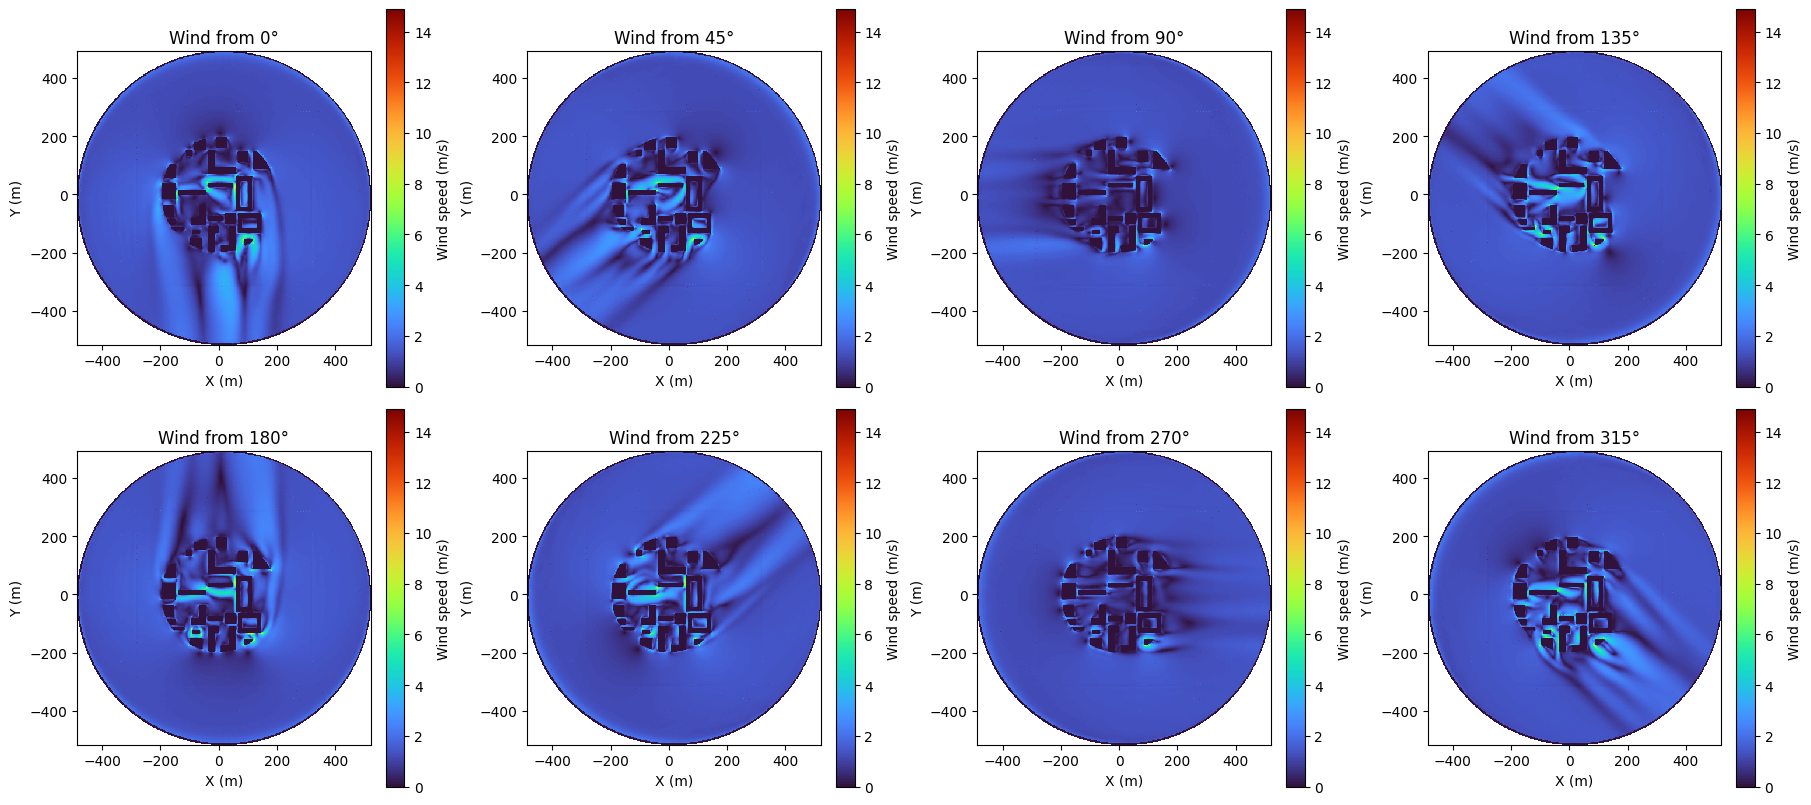

Saved 200,252 points × 8 directions to /content/yel_predictions.csv


In [7]:
directions = list(WIND_DIRECTIONS_DEG)
fig, axes = plt.subplots(
    2, 4, figsize=(18, 8), squeeze=False, constrained_layout=True
)

vmax = float(predictions["wind_speed_m_s"].max()) or 1.0
for axis, direction, view in zip(axes.ravel(), directions, direction_results):
    # Render the complete model grid as an image. This avoids scatter-plot
    # aliasing and is much faster than drawing thousands of individual markers.
    speed_grid = np.full((H, W), np.nan, dtype=np.float32)
    speed_grid[grid_y[valid_mask], grid_x[valid_mask]] = (
        view.loc[valid_mask, "wind_speed_m_s"].to_numpy(dtype=np.float32)
    )
    artist = axis.imshow(
        speed_grid,
        origin="lower",
        extent=[X_MIN - X_STEP / 2, X_MAX + X_STEP / 2,
                Y_MIN - Y_STEP / 2, Y_MAX + Y_STEP / 2],
        cmap="turbo", vmin=0, vmax=vmax,
        interpolation="nearest", aspect="equal",
    )
    axis.set(title=f"Wind from {direction:g}°", xlabel="X (m)", ylabel="Y (m)")
    fig.colorbar(artist, ax=axis, label="Wind speed (m/s)")

plt.show()

# Wide output is substantially faster and smaller than repeating X/Y for every direction.
export = data[["x", "y"]].copy()
for direction, result in zip(directions, direction_results):
    suffix = f"{direction:03d}deg"
    for column in CHANNEL_NAMES:
        if column in result.columns:
            export[f"{column}_{suffix}"] = result[column].to_numpy()

export.to_csv(OUTPUT_CSV, index=False)
print(f"Saved {len(export):,} points × {len(directions)} directions to {OUTPUT_CSV.resolve()}")

## Runtime notes

This notebook is configured for an NVIDIA CUDA runtime such as a Google Colab T4 and pins `onnxruntime-gpu==1.26.0`. ONNX Runtime 1.27 and newer uses CUDA 13 by default, while current T4 notebook images commonly provide CUDA 12. It automatically falls back to the CPU provider if CUDA is unavailable.

`onnxruntime-directml` is for **64-bit Windows**, not a Linux T4 runtime. Do not install it in Colab. If the provider summary above does not list `CUDAExecutionProvider`, verify that the notebook runtime is still set to T4 and restart the session after installing `onnxruntime-gpu`.

For a CPU-only environment, replace `onnxruntime-gpu` with `onnxruntime` in the installation cell.